In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1779636918.845151  324708 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779636918.886168  324708 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779636920.034182  324708 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = '../deep/deep-learning-class/proyecto-final/datasets/Training/'
TEST_DIR = '../deep/deep-learning-class/proyecto-final/datasets/Testing/'

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.


E0000 00:00:1779636981.388407  324708 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779636981.388808  327592 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779636981.410959  324708 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 394 files belonging to 4 classes.


In [6]:
class_names = train_ds.class_names
NUM_CLASES = len(class_names)
print(f"Clases detectadas: {class_names}")

Clases detectadas: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [7]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [9]:
base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

In [10]:
base_model.trainable = False

In [11]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4), 
    layers.Dense(NUM_CLASES, activation='softmax') 
])


In [12]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
print("Fase 1: Entrenando solo el clasificador superior")
history_fase1 = model.fit(train_ds, validation_data=val_ds, epochs=5)

Fase 1: Entrenando solo el clasificador superior
Epoch 1/5


W0000 00:00:1779637057.196523  327612 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1779637057.375330  327612 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3:49 3s/step - accuracy: 0.3125 - loss: 13.3485

W0000 00:00:1779637059.359014  327615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1779637059.415376  327615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


 2/72 ━━━━━━━━━━━━━━━━━━━━ 2:22 2s/step - accuracy: 0.3047 - loss: 37.4931

W0000 00:00:1779637061.396916  327615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


72/72 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.7017 - loss: 8.1589 - val_accuracy: 0.8467 - val_loss: 0.4207
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8510 - loss: 0.4103 - val_accuracy: 0.8798 - val_loss: 0.3141
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8859 - loss: 0.3096 - val_accuracy: 0.8902 - val_loss: 0.2934
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9011 - loss: 0.2642 - val_accuracy: 0.8902 - val_loss: 0.2627
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9029 - loss: 0.2898 - val_accuracy: 0.9164 - val_loss: 0.2816


In [14]:
print("Fase 2: Configurando Fine-Tuning ---")
# Se descongela el modelo base
base_model.trainable = True

Fase 2: Configurando Fine-Tuning ---


In [15]:
# Se congelan todas las capas excepto las que tengan 'block5' en su nombre
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
        print(f"Capa {layer.name} lista para Fine-Tuning")
    else:
        layer.trainable = False

Capa block5_conv1 lista para Fine-Tuning
Capa block5_conv2 lista para Fine-Tuning
Capa block5_conv3 lista para Fine-Tuning
Capa block5_pool lista para Fine-Tuning


In [16]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Entrenamos por más épocas para que los filtros convolucionales médicos se ajusten despacio
history_fase2 = model.fit(train_ds, validation_data=val_ds, epochs=12)

Epoch 1/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9403 - loss: 0.1616 - val_accuracy: 0.9094 - val_loss: 0.2640
Epoch 2/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9556 - loss: 0.1113 - val_accuracy: 0.9338 - val_loss: 0.2515
Epoch 3/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9656 - loss: 0.0939 - val_accuracy: 0.9355 - val_loss: 0.2580
Epoch 4/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9652 - loss: 0.0858 - val_accuracy: 0.9303 - val_loss: 0.2512
Epoch 5/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9739 - loss: 0.0660 - val_accuracy: 0.9286 - val_loss: 0.2728
Epoch 6/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.9804 - loss: 0.0522 - val_accuracy: 0.9286 - val_loss: 0.2518
Epoch 7/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.9782 - loss: 0.0502 - val_accuracy: 0.9303 - val_loss: 0.2732
Epoch 8/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.9843 - loss: 0.0464 - val_accuracy: 0.9094 - v

In [18]:
print("\n--- Evaluando modelo ajustado con el set de Prueba (Testing) ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Precisión final en el set de prueba: {accuracy*100:.2f}%")


--- Evaluando modelo ajustado con el set de Prueba (Testing) ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7259 - loss: 4.6007
Precisión final en el set de prueba: 72.59%


In [19]:
# Metricas 
x_test = []
y_true_encoded = []

for images, labels in test_ds:
    x_test.append(images.numpy())
    y_true_encoded.append(labels.numpy())

x_test = np.concatenate(x_test, axis=0)
y_true_encoded = np.concatenate(y_true_encoded, axis=0)

y_true = np.argmax(y_true_encoded, axis=1)

preds_probabilities = model.predict(x_test)
y_pred = np.argmax(preds_probabilities, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


In [20]:
print("\n" + "="*50)
print("         REPORTE DE CLASIFICACIÓN (VGG16)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*50)


         REPORTE DE CLASIFICACIÓN (VGG16)
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.22      0.35       100
meningioma_tumor       0.64      0.96      0.77       115
        no_tumor       0.72      0.96      0.82       105
 pituitary_tumor       0.93      0.72      0.81        74

        accuracy                           0.73       394
       macro avg       0.80      0.71      0.69       394
    weighted avg       0.78      0.73      0.68       394



In [21]:
# Matriz de confusion
cm = confusion_matrix(y_true, y_pred)

In [22]:
print(cm)

[[ 22  51  24   3]
 [  2 110   2   1]
 [  0   4 101   0]
 [  0   7  14  53]]


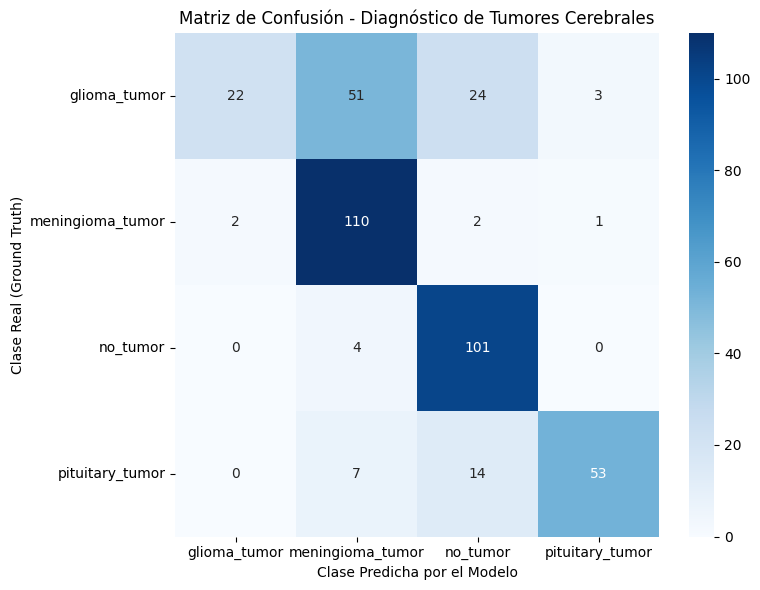

In [26]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Matriz de Confusión - Diagnóstico de Tumores Cerebrales')
plt.ylabel('Clase Real (Ground Truth)')
plt.xlabel('Clase Predicha por el Modelo')
plt.tight_layout()
plt.show()

In [27]:
acc_fase1 = history_fase1.history['accuracy']
val_acc_fase1 = history_fase1.history['val_accuracy']
loss_fase1 = history_fase1.history['loss']
val_loss_fase1 = history_fase1.history['val_loss']

# Extraemos las métricas de la Fase 2 (Fine-Tuning del Bloque 5)
acc_fase2 = history_fase2.history['accuracy']
val_acc_fase2 = history_fase2.history['val_accuracy']
loss_fase2 = history_fase2.history['loss']
val_loss_fase2 = history_fase2.history['val_loss']

# Concatenamos los arreglos para tener la secuencia completa de épocas
total_acc = acc_fase1 + acc_fase2
total_val_acc = val_acc_fase1 + val_acc_fase2
total_loss = loss_fase1 + loss_fase2
total_val_loss = val_loss_fase1 + val_loss_fase2

# Guardamos el número total de épocas y el punto exacto del cambio de fase
total_epochs = len(total_acc)
fase1_epochs = len(acc_fase1)

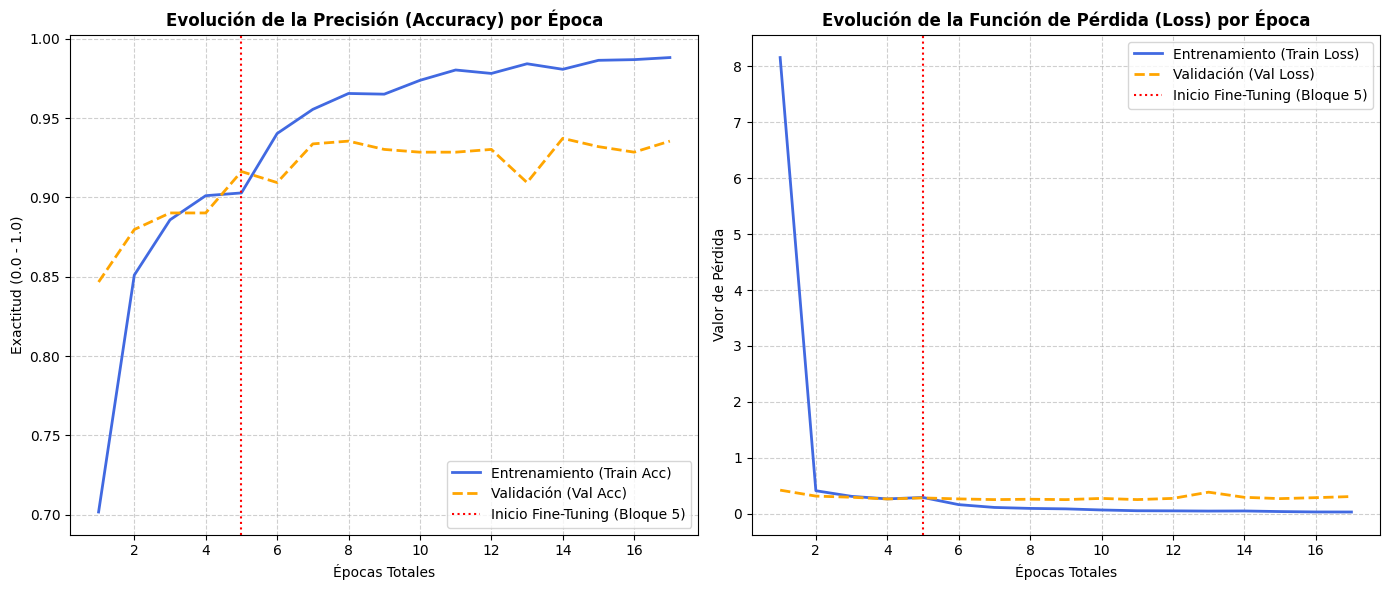

In [28]:
# Graficos de rendimiento
plt.figure(figsize=(14, 6))

# --- Gráfico 1: Precisión (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, total_epochs + 1), total_acc, label='Entrenamiento (Train Acc)', color='royalblue', linewidth=2)
plt.plot(range(1, total_epochs + 1), total_val_acc, label='Validación (Val Acc)', color='orange', linewidth=2, linestyle='--')

# Línea vertical divisoria para marcar el inicio del Fine-Tuning
plt.axvline(x=fase1_epochs, color='red', linestyle=':', label='Inicio Fine-Tuning (Bloque 5)')

plt.title('Evolución de la Precisión (Accuracy) por Época', fontsize=12, fontweight='bold')
plt.xlabel('Épocas Totales', fontsize=10)
plt.ylabel('Exactitud (0.0 - 1.0)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# --- Gráfico 2: Pérdida (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, total_epochs + 1), total_loss, label='Entrenamiento (Train Loss)', color='royalblue', linewidth=2)
plt.plot(range(1, total_epochs + 1), total_val_loss, label='Validación (Val Loss)', color='orange', linewidth=2, linestyle='--')

# Línea vertical divisoria para marcar el inicio del Fine-Tuning
plt.axvline(x=fase1_epochs, color='red', linestyle=':', label='Inicio Fine-Tuning (Bloque 5)')

plt.title('Evolución de la Función de Pérdida (Loss) por Época', fontsize=12, fontweight='bold')
plt.xlabel('Épocas Totales', fontsize=10)
plt.ylabel('Valor de Pérdida', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
# Opcional: Guarda la figura automáticamente para tu informe
plt.savefig('curvas_aprendizaje_vgg16.png', dpi=300)
plt.show()